<a href="https://colab.research.google.com/github/delowerhossentuhin/Feature-Engineering/blob/main/Feature_Extraction%2C_Selection_%26_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

In [ ]:
#Load The Model
model=VGG16()
#Restructure the Model
model=Model(inputs=model.inputs,outputs=model.layers[-2].output)

In [ ]:
drive.mount('/content/drive')
imagepath = "/content/drive/MyDrive/Project and Coding/Feature Engineering in Mona Lisa image Dataset/the_mona_lisa/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
features = {}
image_names = []

for image in os.listdir(imagepath):
    imgPath = os.path.join(imagepath, image)

    # Load and preprocess image
    img = load_img(imgPath, target_size=(224, 224))
    img = img_to_array(img)
    img = img.reshape(1, img.shape[0], img.shape[1], img.shape[2])
    img = preprocess_input(img)

    # Extract features
    feature = model.predict(img, verbose=0)
    features[image] = feature.flatten()  # store with just filename (not full path)
    image_names.append(image)

# Convert features to DataFrame
feature_vectors = np.array(list(features.values()))
df = pd.DataFrame(feature_vectors)

# Add image names as a column
df['image_name'] = image_names

# Load the CSV file
df.to_csv("vgg16_features.csv", index=False)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [ ]:
df.head()


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,image_name
0,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.166258,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.592112,0.000000,0.000000,0.000000,0.000000,image82.jpg
1,0.0,2.000783,0.31043,0.0,2.664936,0.091170,0.070933,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,1.766508,3.584210,1.609348,0.000000,1.372926,0.000000,image75.jpg
2,0.0,0.000000,0.00000,0.0,0.000000,0.377198,0.000000,0.0,1.160530,0.587703,...,0.0,0.000000,0.0,0.000000,1.294476,0.000000,0.369149,0.000000,0.000000,image80.jpg
3,0.0,0.000000,0.00000,0.0,0.730923,0.000000,0.000000,0.0,2.634059,0.000000,...,0.0,2.404616,0.0,1.153143,5.316503,0.000000,0.800209,0.000000,0.502559,image79.jpg
4,0.0,0.000000,0.00000,0.0,5.130317,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,1.938504,0.0,1.971256,0.000000,0.000000,0.000000,0.000000,2.365771,image78.jpg


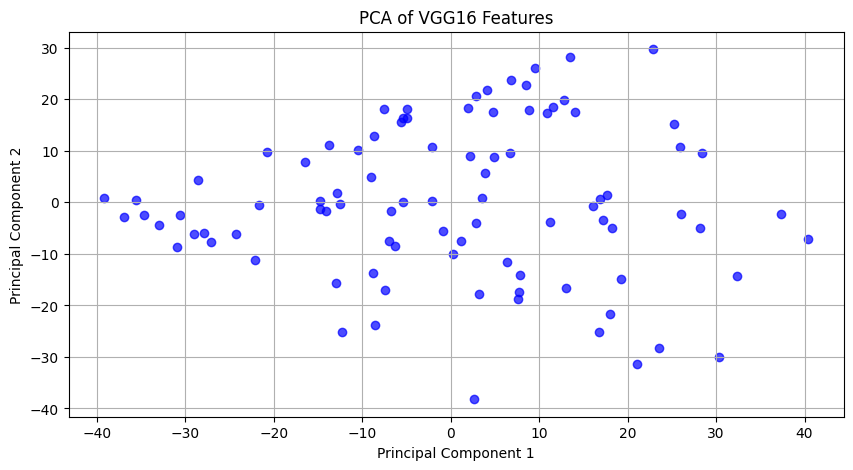

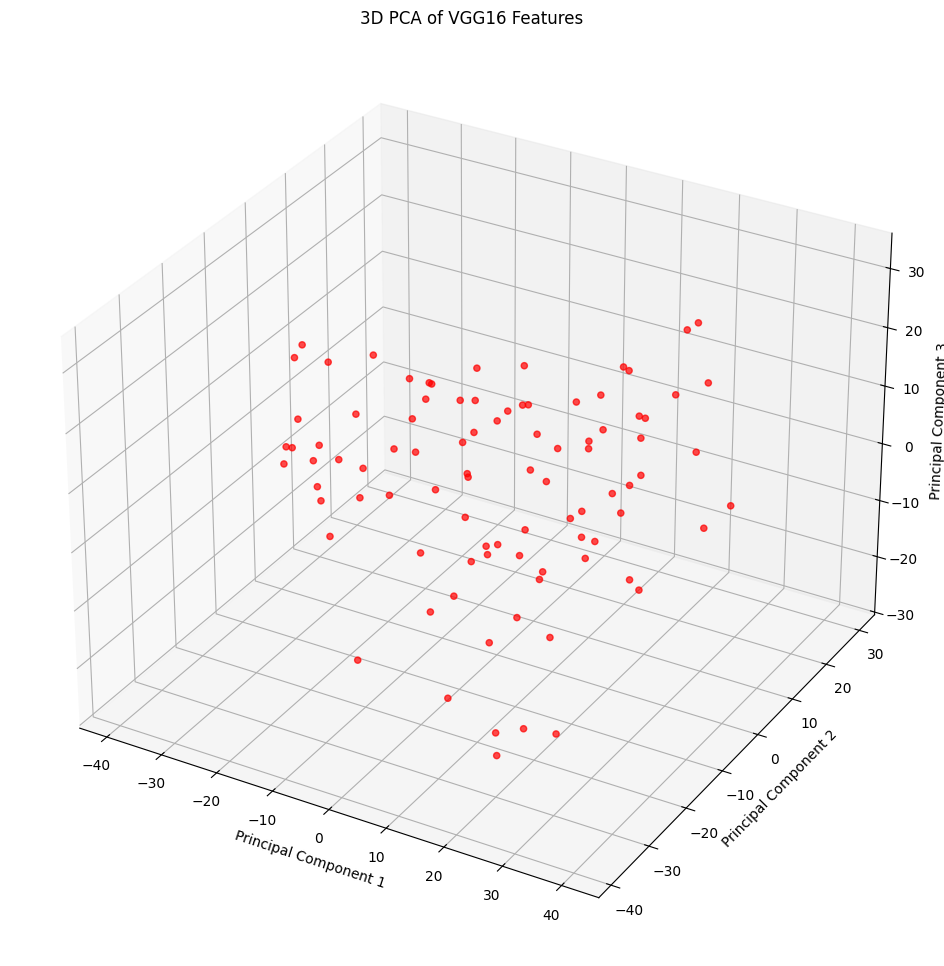

In [ ]:
# Separate features and image names
image_names = df['image_name']
features = df.drop(columns=['image_name'])

# Apply PCA (reduce to 4 components as requested)
pca = PCA(n_components=4)
principal_components = pca.fit_transform(features)

# Create a new DataFrame with PCA results
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3', 'PC4'])
pca_df['image_name'] = image_names

# Save PCA results to CSV
pca_df.to_csv("vgg16_features_pca.csv", index=False)

# Optional: Visualize the PCA result in 2D (using PC1 and PC2 for simplicity)
plt.figure(figsize=(10, 5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='blue', alpha=0.7)

# # Annotate the scatter plot with image names (optional, but can be very crowded)
# for i, name in enumerate(pca_df['image_name']):
#     plt.text(pca_df['PC1'][i], pca_df['PC2'][i], name, fontsize=8)

# Title and labels
plt.title("PCA of VGG16 Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# Optional: 3D Visualization of PC1, PC2, PC3
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c='red', alpha=0.7)

# # Annotate the 3D scatter plot with image names (optional)
# for i, name in enumerate(pca_df['image_name']):
#     ax.text(pca_df['PC1'][i], pca_df['PC2'][i], pca_df['PC3'][i], name, fontsize=8)

ax.set_title("3D PCA of VGG16 Features")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
plt.show()


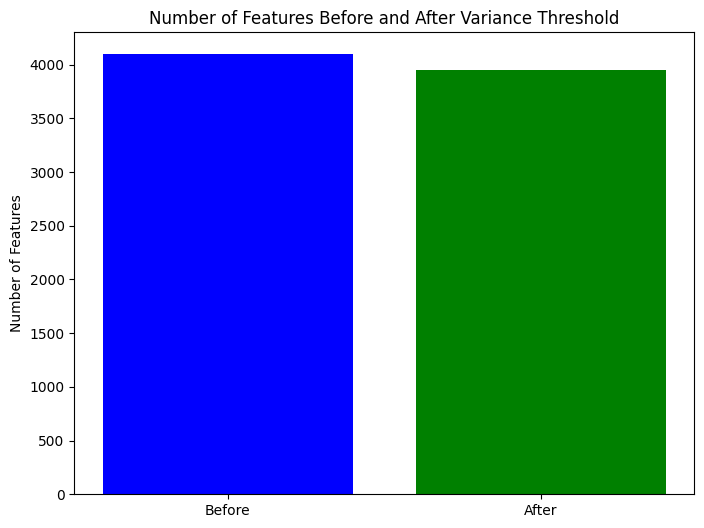

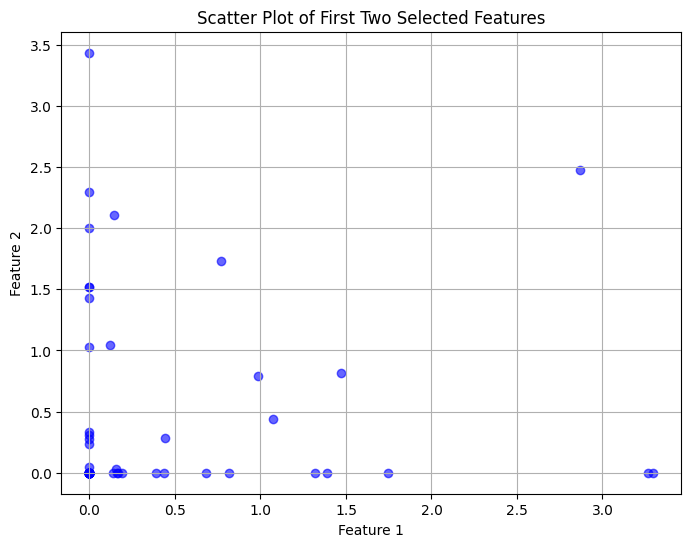

In [ ]:
# Apply Variance Threshold (e.g., remove features with variance < 0.01)
selector = VarianceThreshold(threshold=0.01)
selected_features = selector.fit_transform(features)

# Get selected feature indices
selected_indices = selector.get_support(indices=True)
selected_feature_names = [f"feature_{i}" for i in selected_indices]

# Create DataFrame with selected features
selected_df = pd.DataFrame(selected_features, columns=selected_feature_names)
selected_df['image_name'] = image_names

# Save to CSV
selected_df.to_csv("vgg16_features_variance_threshold.csv", index=False)

# --- Visualization Part ---

# Plot the number of features before and after feature selection
num_features_before = features.shape[1]
num_features_after = selected_features.shape[1]

plt.figure(figsize=(8, 6))
plt.bar(['Before', 'After'], [num_features_before, num_features_after], color=['blue', 'green'])
plt.title('Number of Features Before and After Variance Threshold')
plt.ylabel('Number of Features')
plt.show()

# Optional: Visualize the first two selected features in a scatter plot (if applicable)
if selected_features.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(selected_df.iloc[:, 0], selected_df.iloc[:, 1], c='blue', alpha=0.6)
    plt.title('Scatter Plot of First Two Selected Features')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.show()
